# Tratamento de inputação dos dados

## Bibliotecas

In [1]:
import sys
sys.path.append('/home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks/funcoes')
import pandas as pd
import polars as pl
pl.enable_string_cache()
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
import joblib
from funcoes_de_tratamento import *
import matplotlib.pyplot as plt
from time import perf_counter


/tmp/ipykernel_1212864/1087743236.py:5: DeprecationWarning: the string cache has been replaced by pl.Categories
  pl.enable_string_cache()


# Carregando e filtrando dados

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


/home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks/funcoes/funcoes_de_tratamento.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(lista_dia, ignore_index=True)


Instituições com poucos dados: 5
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


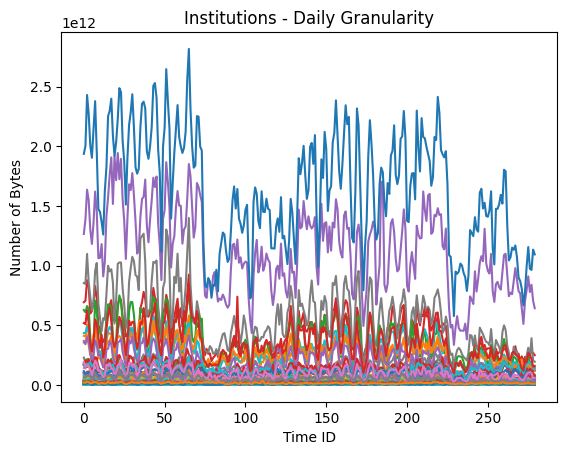

In [2]:

df_day = read_data('../../data/institutions/agg_1_day', features= None)
df_hour = read_data('../../data/institutions/agg_1_hour', features = None)
df_10min = read_data('../../data/institutions/agg_10_minutes', features = None)
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

        '''
    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1
        '''
        
    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]


inst = [int(c) for c in inst]
joblib.dump(inst, "inst.joblib")

  
print()

## Testando multicolineariedade 

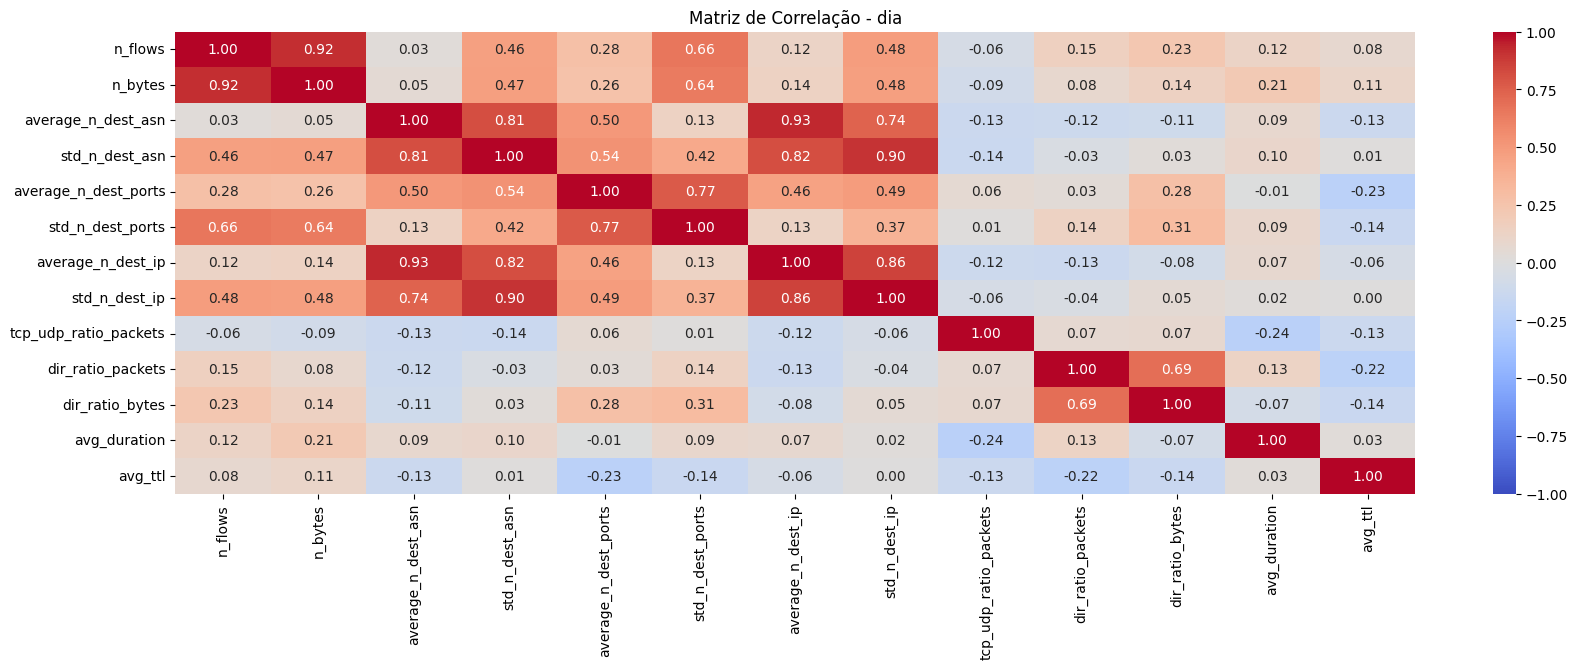

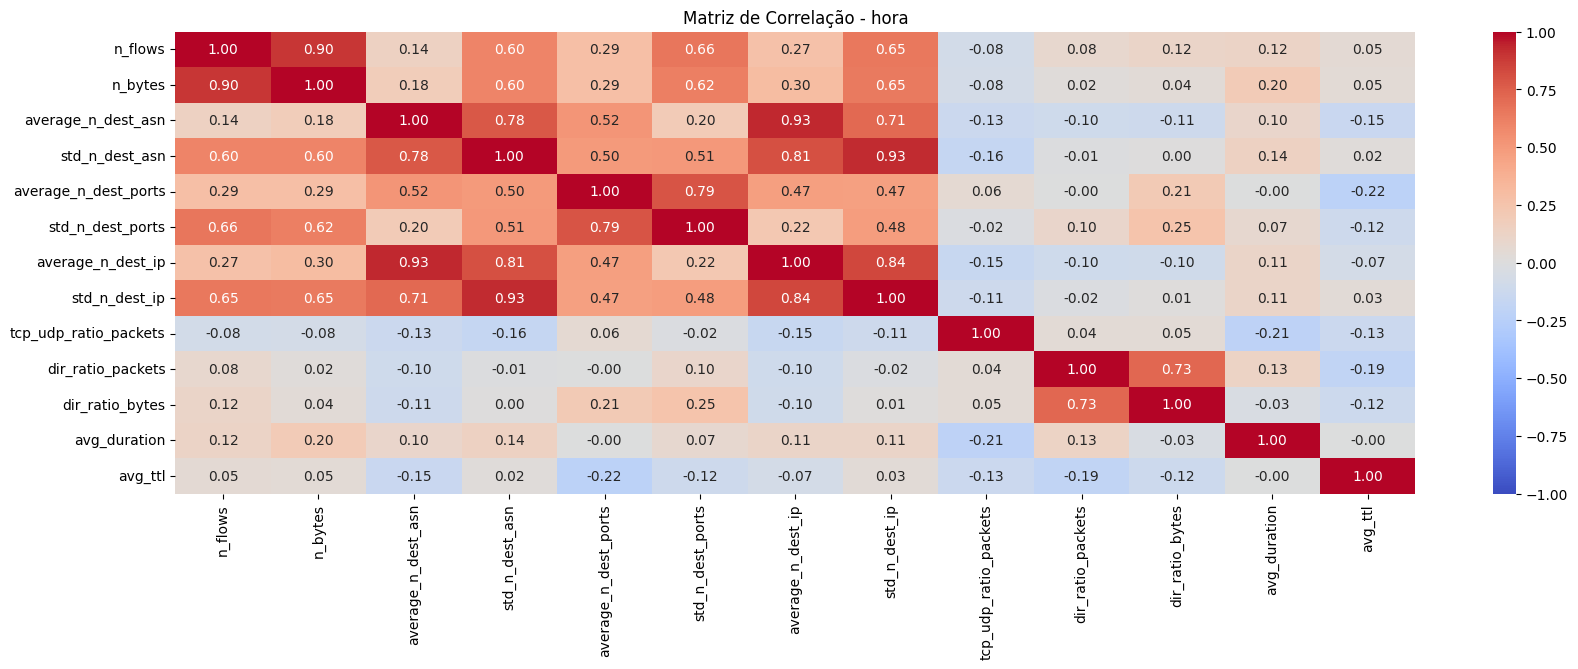

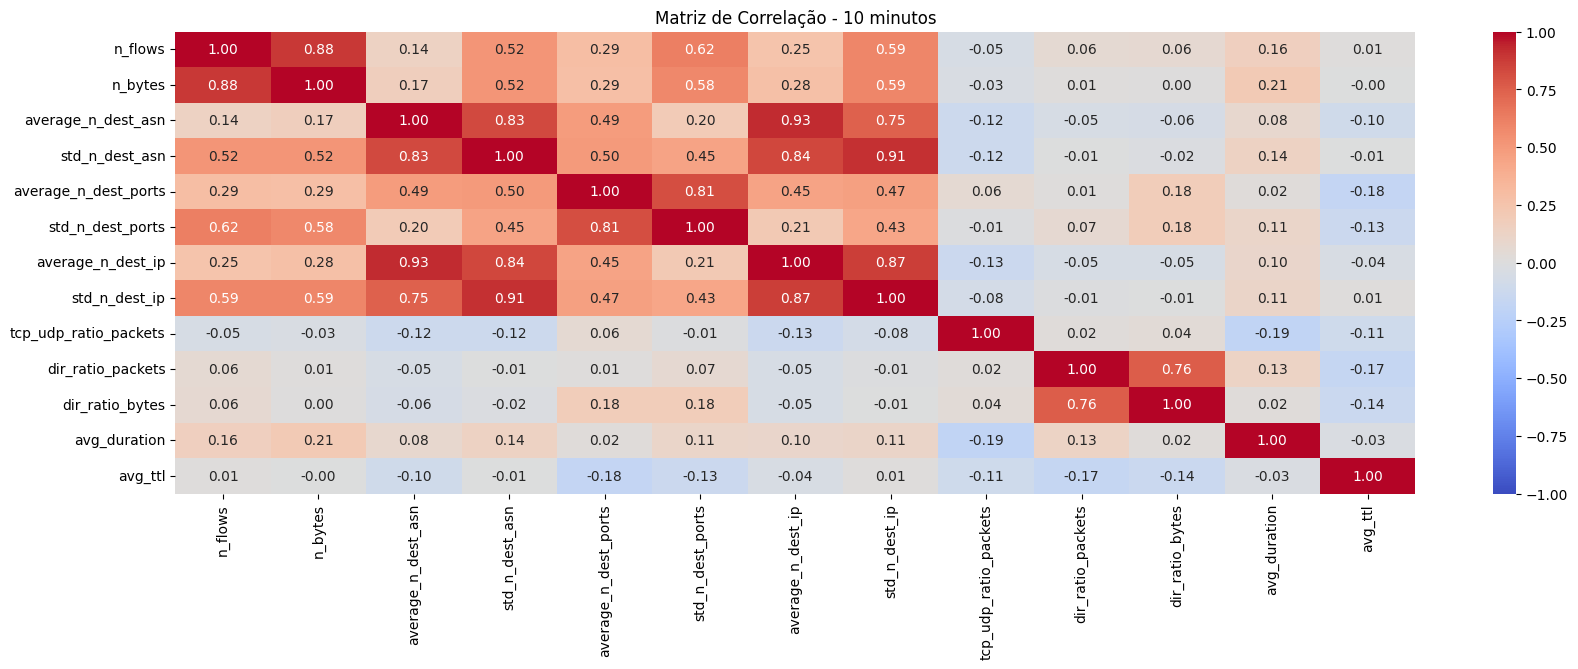

In [7]:
import seaborn as sns
corr = df_day.drop(columns= ["id_time", "id_institution"],axis= 1).corr(method= "spearman")


plt.figure(figsize=(20, 6))

# 4. Plota o Mapa de Calor
sns.heatmap(corr, 
            annot=True,       # Exibe os números dentro de cada quadrado
            cmap='coolwarm',  # Paleta de cores (azul para negativo, vermelho para positivo)
            fmt=".2f",        # Formata os números para 2 casas decimais
            vmin=-1,          # Fixa o limite mínimo da escala de cores em -1
            vmax=1)           # Fixa o limite máximo da escala de cores em 1

# 5. Adiciona título e exibe
plt.title('Matriz de Correlação - dia')
plt.show()

corr = df_hour.drop(columns= ["id_time", "id_institution"],axis= 1).corr(method= "spearman")


plt.figure(figsize=(20, 6))

# 4. Plota o Mapa de Calor
sns.heatmap(corr, 
            annot=True,       # Exibe os números dentro de cada quadrado
            cmap='coolwarm',  # Paleta de cores (azul para negativo, vermelho para positivo)
            fmt=".2f",        # Formata os números para 2 casas decimais
            vmin=-1,          # Fixa o limite mínimo da escala de cores em -1
            vmax=1)           # Fixa o limite máximo da escala de cores em 1

# 5. Adiciona título e exibe
plt.title('Matriz de Correlação - hora')
plt.show()


corr = df_10min.drop(columns= ["id_time", "id_institution"],axis= 1).corr(method= "spearman")


plt.figure(figsize=(20, 6))

# 4. Plota o Mapa de Calor
sns.heatmap(corr, 
            annot=True,       # Exibe os números dentro de cada quadrado
            cmap='coolwarm',  # Paleta de cores (azul para negativo, vermelho para positivo)
            fmt=".2f",        # Formata os números para 2 casas decimais
            vmin=-1,          # Fixa o limite mínimo da escala de cores em -1
            vmax=1)           # Fixa o limite máximo da escala de cores em 1

# 5. Adiciona título e exibe
plt.title('Matriz de Correlação - 10 minutos')
plt.show()


In [3]:
features_redundantes = ["n_packets", "tcp_udp_ratio_bytes"]
for col in df_day.columns:
    if "sum" in col:
        features_redundantes.append(str(col)) 
df_day = df_day.drop(columns=features_redundantes, axis= 1)
df_hour = df_hour.drop(columns=features_redundantes, axis= 1)
df_10min = df_10min.drop(columns=features_redundantes, axis= 1)

/tmp/ipykernel_1212864/90882848.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_acf_grupo)
/tmp/ipykernel_1212864/90882848.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pacfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_pacf_grupo)


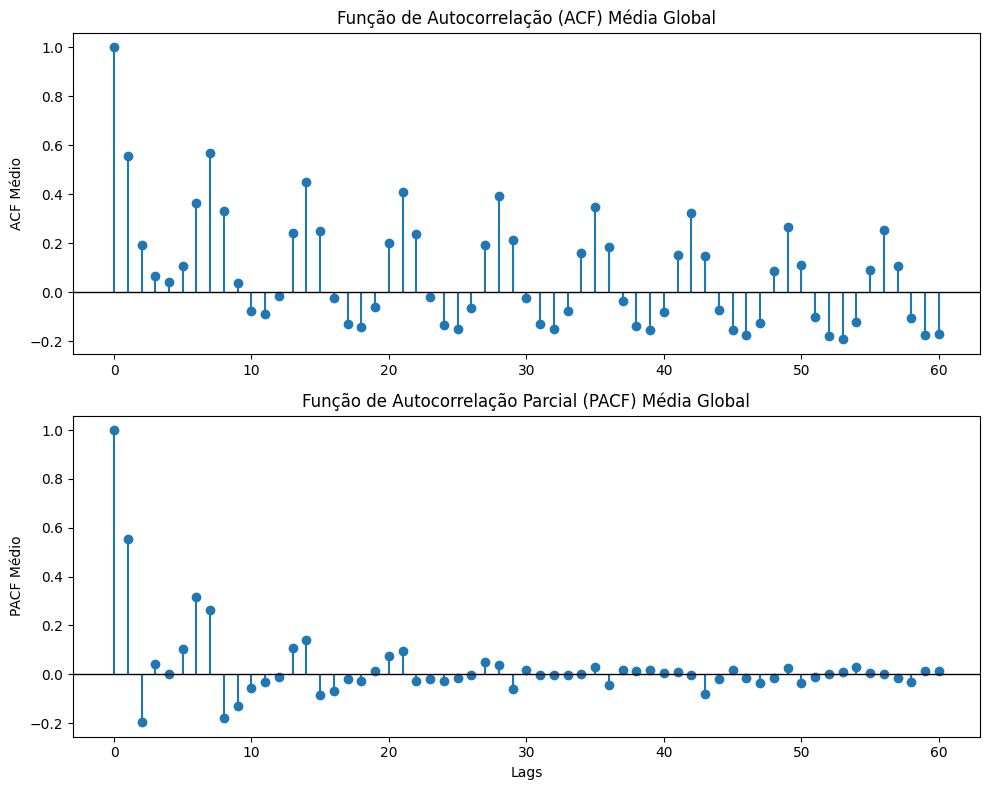

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

# Variáveis de controle
coluna_categoria = 'id_institution' 
coluna_valor = 'n_bytes'         
lags_desejados = 60

# 1. Função para calcular o ACF isolado
def calcular_acf_grupo(grupo):
    nlags_reais = min(lags_desejados, len(grupo) - 2)
    
    if nlags_reais <= 0:
        return np.full(lags_desejados + 1, np.nan) 
        
    resultado_acf = acf(grupo[coluna_valor], nlags=nlags_reais, fft=True)
    
    if len(resultado_acf) < lags_desejados + 1:
        padding = np.full((lags_desejados + 1) - len(resultado_acf), np.nan)
        resultado_acf = np.concatenate((resultado_acf, padding))
        
    return resultado_acf

# 2. Função para calcular o PACF isolado
def calcular_pacf_grupo(grupo):
    # O PACF exige restrição mais forte de lags (menor que a metade do tamanho da série)
    nlags_reais = min(lags_desejados, (len(grupo) // 2) - 1)
    
    if nlags_reais <= 0:
        return np.full(lags_desejados + 1, np.nan) 
        
    # Usando method='ywm' (o método padrão e eficiente do PACF, já que não possui fft=True)
    resultado_pacf = pacf(grupo[coluna_valor], nlags=nlags_reais, method='ywm')
    
    if len(resultado_pacf) < lags_desejados + 1:
        padding = np.full((lags_desejados + 1) - len(resultado_pacf), np.nan)
        resultado_pacf = np.concatenate((resultado_pacf, padding))
        
    return resultado_pacf

# 3. Aplica a função por categoria
acfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_acf_grupo)
pacfs_por_categoria = df_day.groupby(coluna_categoria).apply(calcular_pacf_grupo)

# 4. Converte o resultado em um DataFrame 
df_acfs = pd.DataFrame(acfs_por_categoria.tolist(), index=acfs_por_categoria.index)
df_pacfs = pd.DataFrame(pacfs_por_categoria.tolist(), index=pacfs_por_categoria.index)

# 5. Calcula a média para cada lag (ignorando NaNs)
acf_medio = df_acfs.mean(axis=0)
pacf_medio = df_pacfs.mean(axis=0)

# 6. Plotando os dois resultados em gráficos empilhados
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot do ACF
axes[0].stem(range(len(acf_medio)), acf_medio, basefmt=" ")
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Função de Autocorrelação (ACF) Média Global')
axes[0].set_ylabel('ACF Médio')

# Plot do PACF
axes[1].stem(range(len(pacf_medio)), pacf_medio, basefmt=" ")
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Função de Autocorrelação Parcial (PACF) Média Global')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF Médio')

plt.tight_layout()
plt.show()

## Tranformando ids temporais faltantes em espaços em branco

### Identificando ids faltantes

In [5]:
time_day = pd.read_csv('../../data/times/times_1_day.csv')
time_hour = pd.read_csv('../../data/times/times_1_hour.csv')
time_minute = pd.read_csv('../../data/times/times_10_minutes.csv')

df_day["id_time"] = df_day["id_time"].astype(int)
df_hour["id_time"] = df_hour["id_time"].astype(int)
df_10min["id_time"] = df_10min["id_time"].astype(int)

df_day = df_day.merge(time_day, on="id_time", how="left")
df_day["time"] = pd.to_datetime(df_day["time"])
df_day["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_day["time"].dt.year.astype("int"),
            "month": df_day["time"].dt.month.astype("int"),
            "day": df_day["time"].dt.day.astype("int"),
            "hour": df_day["time"].dt.hour.astype("int"),
            "minute": (round(df_day["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_day["id_institution"] = df_day["id_institution"].astype("int")
df_day = df_day.sort_values(by = ["time", "id_institution"])
df_day.drop(columns=["id_time"], inplace=True)

df_hour = df_hour.merge(time_hour, on="id_time", how="left")
df_hour["time"] = pd.to_datetime(df_hour["time"])
df_hour["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": (round(df_hour["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)
df_hour["id_institution"] = df_hour["id_institution"].astype("int")
df_hour = df_hour.sort_values(by = ["time", "id_institution"])
df_hour.drop(columns=["id_time"], inplace=True)

df_10min = df_10min.merge(time_minute, on="id_time", how="left")
df_10min["time"] = pd.to_datetime(df_10min["time"], utc = True)
df_10min["time"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": (round(df_10min["time"].dt.minute.astype("int") /10))*10,
            "second": 0

        }
    )
)

df_10min["id_institution"] = df_10min["id_institution"].astype("int")
df_10min = df_10min.sort_values(by = ["time", "id_institution"])
df_10min.drop(columns=["id_time"], inplace=True)


### Criando mascara temporal e ligando com os dados

In [6]:
series_day = pd.Series( pd.date_range(start = df_day["time"].min(), end = df_day["time"].max(), freq = "D"), name = "time")
display(series_day)

series_hour = pd.Series(pd.date_range(start=df_hour["time"].min(), end=df_hour["time"].max(), freq='h'), name="time")
display(series_hour)

series_10min = pd.Series(pd.date_range(start=df_10min["time"].min(), end=df_10min["time"].max(), freq='10min'), name="time")
display(series_10min)


0     2023-10-09
1     2023-10-10
2     2023-10-11
3     2023-10-12
4     2023-10-13
         ...    
275   2024-07-10
276   2024-07-11
277   2024-07-12
278   2024-07-13
279   2024-07-14
Name: time, Length: 280, dtype: datetime64[ns]

0      2023-10-09 00:00:00
1      2023-10-09 01:00:00
2      2023-10-09 02:00:00
3      2023-10-09 03:00:00
4      2023-10-09 04:00:00
               ...        
6713   2024-07-14 17:00:00
6714   2024-07-14 18:00:00
6715   2024-07-14 19:00:00
6716   2024-07-14 20:00:00
6717   2024-07-14 21:00:00
Name: time, Length: 6718, dtype: datetime64[ns]

0       2023-10-09 00:00:00
1       2023-10-09 00:10:00
2       2023-10-09 00:20:00
3       2023-10-09 00:30:00
4       2023-10-09 00:40:00
                ...        
40303   2024-07-14 21:10:00
40304   2024-07-14 21:20:00
40305   2024-07-14 21:30:00
40306   2024-07-14 21:40:00
40307   2024-07-14 21:50:00
Name: time, Length: 40308, dtype: datetime64[ns]

In [10]:
dfs = []
for id in inst:
    df_d = df_day[df_day["id_institution"] ==  id].copy()
    df_d = df_d.merge(series_day, on = "time", how = "right")
    df_d["id_institution"] = df_d["id_institution"].fillna(id).astype("int")
    df_d["n_bytes"] = df_d["n_bytes"].bfill().ffill()
    dfs.append(df_d)

df_day = pd.concat(dfs)


dfs = []
for id in inst:
    df_h = df_hour[df_hour["id_institution"] ==  id].copy()
    df_h = df_h.merge(series_hour, on = "time", how = "right")
    
    df_h["id_institution"] =df_h["id_institution"].fillna(id).astype("int")
    dfs.append(df_h)

df_hour = pd.concat(dfs)

dfs = []
for id in inst:
    df_m = df_10min[df_10min["id_institution"] ==  id].copy()
    df_m = df_m.merge(series_10min, on = "time", how = "right")
    df_m["id_institution"] = df_m["id_institution"].fillna(id).astype("int")
    dfs.append(df_m)

df_10min = pd.concat(dfs)

In [7]:
df_day["time_d"] = df_day["time"].dt.date
df_hour["time_d"] = df_hour["time"].dt.date
df_hour["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_hour["time"].dt.year.astype("int"),
            "month": df_hour["time"].dt.month.astype("int"),
            "day": df_hour["time"].dt.day.astype("int"),
            "hour": df_hour["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

df_10min["time_h"] = pd.to_datetime(pd.DataFrame(
        {
            "year": df_10min["time"].dt.year.astype("int"),
            "month": df_10min["time"].dt.month.astype("int"),
            "day": df_10min["time"].dt.day.astype("int"),
            "hour": df_10min["time"].dt.hour.astype("int"),
            "minute": 0,
            "second": 0

        }
    )
)

In [8]:
df_day_ = df_day.copy()
del df_day
df_hour_ = df_hour.copy()
del df_hour
df_10min_ = df_10min.copy()
del df_10min

In [10]:
df_day = df_day_
df_hour = df_hour_
df_10min = df_10min_

In [ ]:
df_10min["n_flows"] = df_10min

## XGboost para escolha de variáveis

Lags originais: 12
Lags retidos após corte: 5
Lista de variáveis mantidas: ['n_flows', 'average_n_dest_asn', 'average_n_dest_ip', 'std_n_dest_asn', 'average_n_dest_ports']


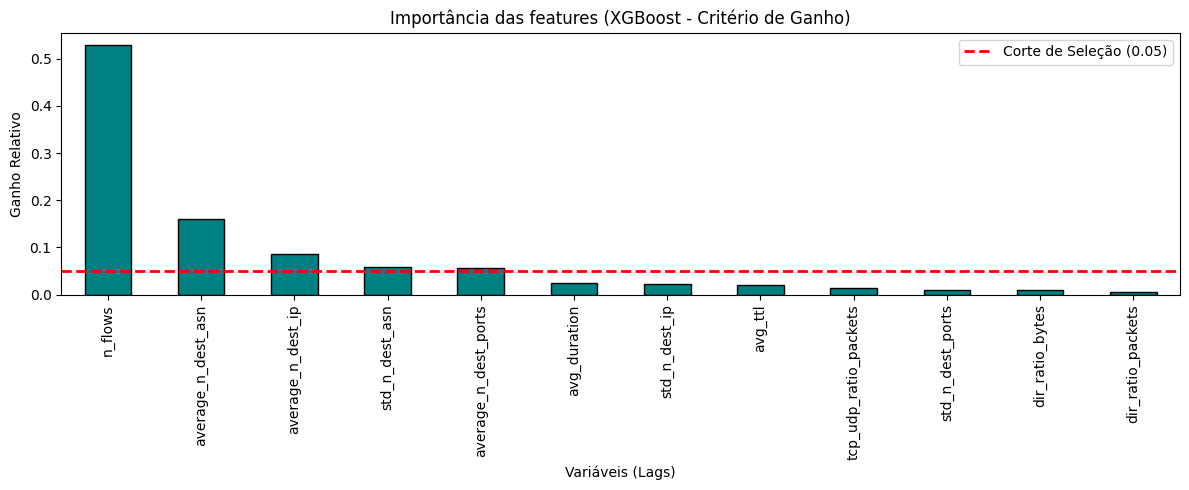

Lags originais: 12
Lags retidos após corte: 4
Lista de variáveis mantidas: ['n_flows', 'std_n_dest_asn', 'average_n_dest_ip', 'average_n_dest_asn']


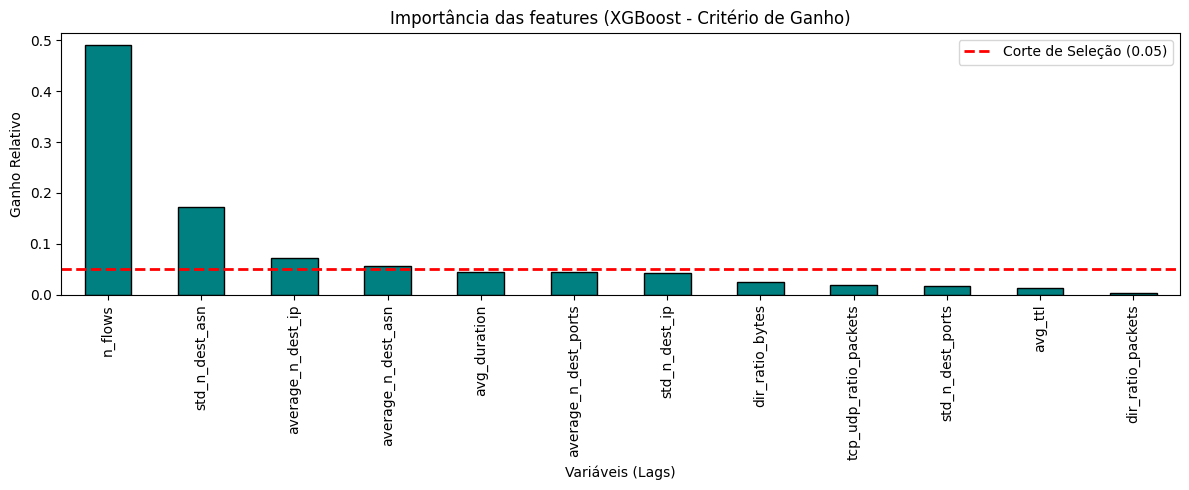

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:n_flows: object

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
def xgboost_train(df_day, drop_features: list):
    np.random.seed(42)
    for col in df_day.columns:
        df_day[col] = df_day[col].fillna(-1)
    X = df_day.drop(columns=drop_features, axis = 1)
    # Simulando que apenas o lag_1 e lag_5 têm relação real com o alvo:
    y = df_day["n_bytes"]

    # ---------------------------------------------------------
    # 1. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
    # ---------------------------------------------------------
    # Utilize parâmetros conservadores (max_depth baixo) para evitar 
    # que o modelo decore o ruído (overfitting) e gere falsas importâncias.
    modelo_xgb = xgb.XGBRegressor(
        n_estimators=100,    # Número de árvores
        max_depth=4,         # Profundidade máxima (4 a 6 é o ideal para seleção)
        learning_rate=0.1,   # Taxa de aprendizado
        random_state=42
    )

    # Treina o modelo na matriz completa
    modelo_xgb.fit(X, y)

    # ---------------------------------------------------------
    # 2. EXTRAÇÃO DAS IMPORTÂNCIAS
    # ---------------------------------------------------------
    # Extrai o array de importâncias e converte em uma Série do Pandas
    importancias = pd.Series(modelo_xgb.feature_importances_, index=X.columns)
    importancias_ordenadas = importancias.sort_values(ascending=False)

    # ---------------------------------------------------------
    # 3. APLICAÇÃO DO CORTE (THRESHOLD)
    # ---------------------------------------------------------
    # Defina o critério rigoroso para manter uma coluna. 
    # Aqui, mantemos apenas lags cuja importância seja maior que 1% (0.01).
    limiar_corte = 0.05
    lags_selecionados = importancias_ordenadas[importancias_ordenadas > limiar_corte].index

    print(f"Lags originais: {X.shape[1]}")
    print(f"Lags retidos após corte: {len(lags_selecionados)}")
    print(f"Lista de variáveis mantidas: {list(lags_selecionados)}")

    # 4. GERAÇÃO DA MATRIZ REDUZIDA
    # Esta é a matriz final que você usará no seu pipeline real
    X_reduzido = X[lags_selecionados]

    # ---------------------------------------------------------
    # 5. VISUALIZAÇÃO DOS RESULTADOS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5))
    # Plota apenas os top 20 para manter o gráfico legível
    importancias_ordenadas.head(20).plot(kind='bar', color='teal', edgecolor='black')
    plt.axhline(limiar_corte, color='red', linestyle='--', linewidth=2, label=f'Corte de Seleção ({limiar_corte})')

    plt.title('Importância das features (XGBoost - Critério de Ganho)')
    plt.ylabel('Ganho Relativo')
    plt.xlabel('Variáveis (Lags)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return lags_selecionados

features_day = xgboost_train(df_day, ["id_institution", "time", "n_bytes", "time_d"])
features_hour = xgboost_train(df_hour, ["id_institution", "time", "n_bytes", "time_d", "time_h"])
features_10min = xgboost_train(df_10min, ["id_institution", "time", "n_bytes", "time_h"])

features = list(set(features_day) | set(features_hour) | set(features_10min))

In [26]:
features

['average_n_dest_ip',
 'avg_duration',
 'std_n_dest_asn',
 'n_flows',
 'average_n_dest_ports',
 'average_n_dest_asn']

In [27]:
df_day= df_day[features]
df_hour = df_hour[features]
df_10min = df_10min[features]

In [28]:
df_day

,average_n_dest_ip,avg_duration,std_n_dest_asn,n_flows,average_n_dest_ports,average_n_dest_asn
0,62.55,16.23,20.72,480822,5.63,10.73
1,56.34,16.06,18.62,402227,4.93,10.02
2,59.19,14.29,18.85,456772,5.49,10.56
3,62.86,14.09,21.15,486108,5.49,11.41
4,63.37,12.87,22.68,508390,6.23,12.61
...,...,...,...,...,...,...
275,37.08,16.27,18.52,149286,15.45,9.66
276,38.39,15.79,17.37,134146,15.77,9.31
277,35.45,16.28,16.41,126761,12.90,9.26
278,16.45,16.23,7.09,50625,11.40,6.79


## Testando técnicas de imputação

### resetando nulos

In [ ]:
df_hour = df_hour_.copy()
df_10min = df_10min_.copy()

NameError: name 'df_hour_' is not defined

In [ ]:
elapsed_time = {
    "granufill": {"hour": None, "10min": None},
    "mavg_fill": {"hour": None, "10min": None},
    "mmedian_fill": {"hour": None, "10min": None},
    "knn_fill": {"hour": None, "10min": None},
    "svd_fill": {"hour": None, "10min": None},
}

### Granufill

In [ ]:


start = perf_counter()
df_hour = granufill(df_day, df_hour, ["id_institution", "time"], "n_bytes", 24)
end = perf_counter()
elapsed_time["granufill"]["hour"] = end - start

start = perf_counter()
df_10min = granufill(df_hour, df_10min, ["id_institution", "time"], "n_bytes", 24*6)
end = perf_counter()
elapsed_time["granufill"]["10min"] = end - start

### Média Móvel

In [ ]:

start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = moving_average_fill(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["mavg_fill"]["hour"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = moving_average_fill(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["mavg_fill"]["10min"] = end - start

### Mediana móvel

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = moving_median_fill(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["mmedian_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = moving_median_fill(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["mmedian_fill"]["10min"] = end - start

### KNN

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = knn_fill_missing(df_hour[filtro_hour, "n_bytes" ], k = 24)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = knn_fill_missing(df_10min.loc[filtro_10min, "n_bytes" ], k = 24*6)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

### SVD

In [ ]:
start = perf_counter()
for id in inst:
    filtro_hour = df_hour["id_institution"] == id
    df_hour.loc[filtro_hour, "n_bytes" ] = svd_fill_missing(df_hour[filtro_hour, "n_bytes" ], window_size = 24)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

start = perf_counter()
for id in inst:
    filtro_10min = df_10min["id_institution"] == id
    df_10min.loc[filtro_10min, "n_bytes" ] = svd_fill_missing(df_10min.loc[filtro_10min, "n_bytes" ], window_size= 24*6)
end = perf_counter()
elapsed_time["knn_fill"]["10min"] = end - start

## Resultados:

In [ ]:
print(f"""Tempo de execução de cada método:

GRANUFILL:
    Horário: {elapsed_time['granufill']['hour']}
    10 min:  {elapsed_time['granufill']['10min']}

MÉDIA MÓVEL (mavg_fill):
    Horário: {elapsed_time['mavg_fill']['hour']}
    10 min:  {elapsed_time['mavg_fill']['10min']}

MEDIANA MÓVEL (mmedian_fill):
    Horário: {elapsed_time['mmedian_fill']['hour']}
    10 min:  {elapsed_time['mmedian_fill']['10min']}

KNN (knn_fill):
    Horário: {elapsed_time['knn_fill']['hour']}
    10 min:  {elapsed_time['knn_fill']['10min']}

SVD (svd_fill):
    Horário: {elapsed_time['svd_fill']['hour']}
    10 min:  {elapsed_time['svd_fill']['10min']}
""")


In [ ]:
atributos = ["time", "id_institution", "n_bytes"]
df_day = df_day[atributos].drop_duplicates()
df_hour = df_hour[atributos].drop_duplicates()
df_10min = df_10min[atributos].drop_duplicates()

In [ ]:
display(df_day)
display(df_hour)
display(df_10min)

,time,id_institution,n_bytes
0,2023-10-09,137,104254214117
1,2023-10-10,137,77598243579
2,2023-10-11,137,107828916252
3,2023-10-12,137,75404450175
4,2023-10-13,137,73054357548
...,...,...,...
275,2024-07-10,83,20056212285
276,2024-07-11,83,9558339042
277,2024-07-12,83,11933568726
278,2024-07-13,83,8496556858


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,2.979420e+09
1,2023-10-09 01:00:00,137,1.054940e+09
2,2023-10-09 02:00:00,137,1.699339e+10
3,2023-10-09 03:00:00,137,4.096599e+09
4,2023-10-09 04:00:00,137,2.537641e+09
...,...,...,...
685231,2024-07-14 17:00:00,83,8.969877e+08
685232,2024-07-14 18:00:00,83,7.066403e+08
685233,2024-07-14 19:00:00,83,1.275217e+07
685234,2024-07-14 20:00:00,83,7.482055e+08


,time,id_institution,n_bytes
0,2023-10-09 00:00:00,137,796727424
1,2023-10-09 00:10:00,137,35517598
2,2023-10-09 00:20:00,137,22809023
3,2023-10-09 00:30:00,137,46543563
4,2023-10-09 00:40:00,137,2019183184
...,...,...,...
4111411,2024-07-14 21:10:00,83,3511381
4111412,2024-07-14 21:20:00,83,1774880
4111413,2024-07-14 21:30:00,83,668945468
4111414,2024-07-14 21:40:00,83,53912021


In [ ]:
display(df_day[df_day["n_bytes"].isna()])
display(df_hour[df_hour["n_bytes"].isna()])
display(df_10min[df_10min["n_bytes"].isna()])

,time,id_institution,n_bytes


,time,id_institution,n_bytes


,time,id_institution,n_bytes


## Salvando dados inputados

In [ ]:
df_day.to_parquet("../../data/tratados/df_day.parquet")
df_hour.to_parquet("../../data/tratados/df_hour.parquet")
df_10min.to_parquet("../../data/tratados/df_10min.parquet")